# Phase 4 — Business Insights & Visualization
Self-contained notebook: reloads raw data plus everything saved by the Phase 2 and Phase 3 notebooks from `data/processed/`. Each question below = 1 chart + 1 written interpretation. The interpretation sentences you write here are almost exactly what goes in your report's Findings & Insights section — write them as you go.

In [32]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import matplotlib.ticker as mticker

RAW = Path("data/raw")
PROCESSED = Path("data/processed")

sns.set_style("whitegrid")  # consistent look across all charts in the report

## Reload everything this notebook needs

In [33]:
# --- Raw ---
con = sqlite3.connect(RAW / "ecommerce.db")
orders = pd.read_sql("SELECT * FROM orders", con)
customers = pd.read_sql("SELECT * FROM customers", con)
products = pd.read_sql("SELECT * FROM products", con)
web_sessions = pd.read_sql("SELECT * FROM web_sessions", con)
reviews = pd.read_sql("SELECT * FROM reviews", con)
con.close()

orders["order_date"] = pd.to_datetime(orders["order_date"])
web_sessions["session_date"] = pd.to_datetime(web_sessions["session_date"])
orders_completed = orders[orders["status"] == "completed"].copy()

# --- Phase 2 outputs ---
order_items_clean = pd.read_csv(PROCESSED / "clean_order_items.csv")
category_month_revenue = pd.read_csv(PROCESSED / "category_month_revenue.csv", index_col=0)

# --- Phase 3 outputs ---
rfm_raw = pd.read_csv(PROCESSED / "rfm_segments.csv")
beta = np.load(PROCESSED / "regression_beta.npy")

print("All inputs loaded.")

All inputs loaded.


---
## Q1 — Which RFM segment generates the most revenue, and what distinguishes it demographically?

In [34]:
segment_revenue = rfm_raw.groupby("segment")["monetary"].sum().sort_values(ascending=False)
print(segment_revenue)

top_segment = segment_revenue.idxmax()
print(f"\nTop segment by revenue: {top_segment}")

# Demographics: merge RFM segments with customer info
rfm_demo = rfm_raw.merge(customers, on="customer_id")
demo_summary = rfm_demo.groupby("segment").agg(
    avg_age=("age", "mean"),
    top_country=("country", lambda x: x.mode()[0] if not x.mode().empty else None),
    pct_female=("gender", lambda x: (x == "F").mean()),
).round(2)
print(demo_summary)

segment
Champions    3.631510e+06
Loyal        2.714330e+06
At Risk      9.494693e+05
Lost         2.741782e+05
Name: monetary, dtype: float64

Top segment by revenue: Champions
           avg_age top_country  pct_female
segment                                   
At Risk      44.63         USA        0.49
Champions    45.93         USA        0.41
Lost         44.29         USA        0.51
Loyal        45.45         USA        0.48


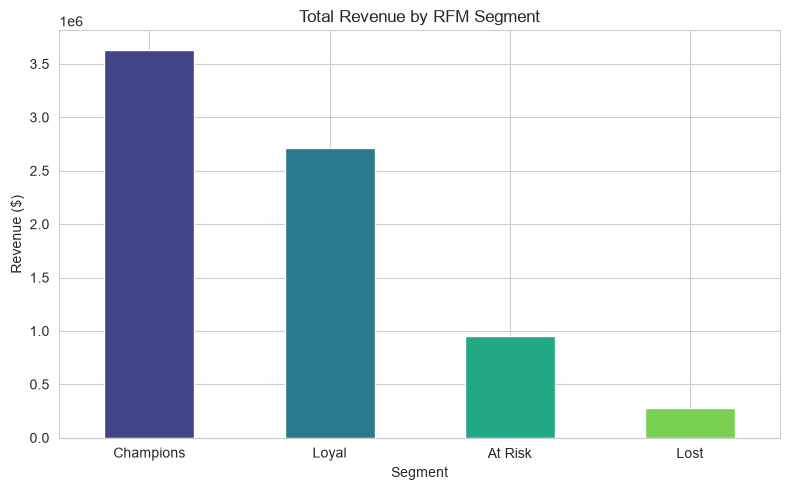

In [35]:
fig, ax = plt.subplots(figsize=(8, 5))
segment_revenue.plot(kind="bar", ax=ax, color=sns.color_palette("viridis", len(segment_revenue)))
ax.set_title("Total Revenue by RFM Segment")
ax.set_ylabel("Revenue ($)")
ax.set_xlabel("Segment")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(PROCESSED.parent / "chart_q1_segment_revenue.png", dpi=150)
plt.show()

**Write your interpretation here** — e.g. "*Champions* generate $X, driven by an average age of Y and a concentration in [country]..." Fill in with your actual numbers from above.

---
## Q2 — Is there seasonality in overall revenue?

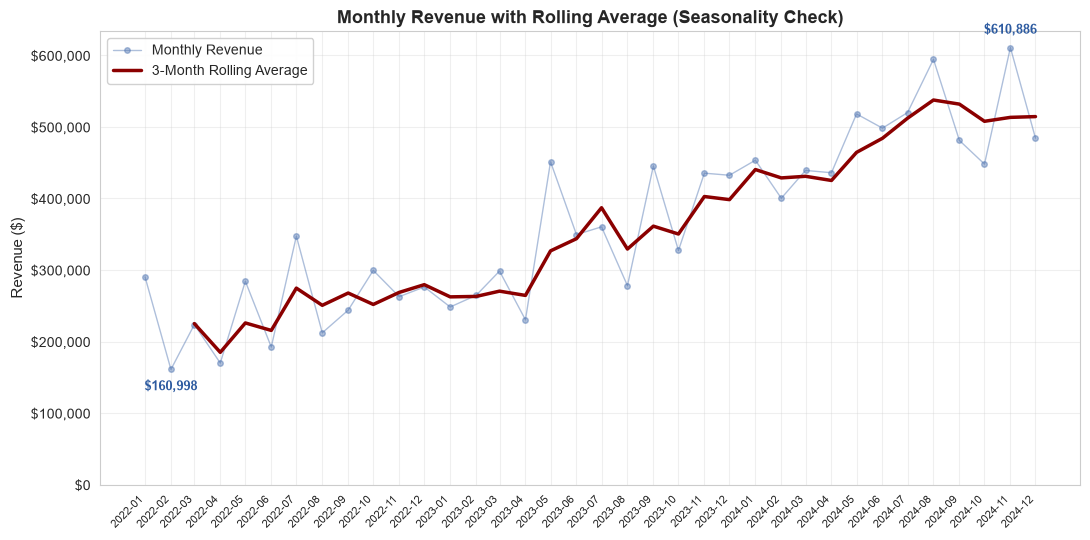

In [36]:
monthly_revenue = category_month_revenue.sum(axis=0).sort_index()
monthly_revenue.index = pd.to_datetime(monthly_revenue.index)

rolling_avg = monthly_revenue.rolling(window=3).mean()

fig, ax = plt.subplots(figsize=(11, 5.5))

ax.plot(monthly_revenue.index, monthly_revenue.values, marker="o", markersize=4,
        color="#4C72B0", linewidth=1, alpha=0.45, label="Monthly Revenue", zorder=1)
ax.plot(rolling_avg.index, rolling_avg.values, linewidth=2.5, color="darkred",
        label="3-Month Rolling Average", zorder=2)

# --- Format y-axis as real currency: $400,000 instead of 400000 ---
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

# --- Start y-axis at 0 so bar-to-bar height differences read honestly ---
ax.set_ylim(bottom=0)

# --- Mark the single highest and lowest month explicitly ---
peak_idx = monthly_revenue.idxmax()
trough_idx = monthly_revenue.idxmin()
ax.annotate(f"${monthly_revenue[peak_idx]:,.0f}",
            xy=(peak_idx, monthly_revenue[peak_idx]),
            xytext=(0, 10), textcoords="offset points",
            ha="center", fontsize=9, fontweight="bold", color="#2c5aa0")
ax.annotate(f"${monthly_revenue[trough_idx]:,.0f}",
            xy=(trough_idx, monthly_revenue[trough_idx]),
            xytext=(0, -15), textcoords="offset points",
            ha="center", fontsize=9, fontweight="bold", color="#2c5aa0")

# --- Cleaner x-axis: show every month, but rotated + smaller font so it doesn't overlap ---
ax.set_xticks(monthly_revenue.index)
ax.set_xticklabels([d.strftime("%Y-%m") for d in monthly_revenue.index], rotation=45, ha="right", fontsize=8)

ax.set_title("Monthly Revenue with Rolling Average (Seasonality Check)", fontsize=13, fontweight="bold")
ax.set_ylabel("Revenue ($)", fontsize=11)
ax.legend(loc="upper left", framealpha=0.9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PROCESSED.parent / "chart_q2_seasonality.png", dpi=150)
plt.show()

**Write your interpretation here** — which calendar months are consistently highest/lowest, and does the rolling average show a clear repeating pattern or just random noise?

---
## Q3 — Which category has the highest effective margin (after discounts + returns)?

In [37]:
# net_revenue already accounts for discounts and returns (negative quantity) from Phase 2.
# We need NET COST the same way: quantity (signed) * unit cost, so a return also reverses its cost.
oi_margin = order_items_clean.merge(products[["product_id", "category", "cost"]], on="product_id")
oi_margin["net_cost"] = oi_margin["quantity"] * oi_margin["cost"]

category_margin = oi_margin.groupby("category").agg(
    net_revenue=("net_revenue", "sum"),
    net_cost=("net_cost", "sum"),
)
category_margin["effective_margin_pct"] = (
    (category_margin["net_revenue"] - category_margin["net_cost"]) / category_margin["net_revenue"]
) * 100
category_margin = category_margin.sort_values("effective_margin_pct", ascending=False)
print(category_margin)

                    net_revenue   net_cost  effective_margin_pct
category                                                        
Books & Media      3.659344e+06  806766.83             77.953239
Beauty & Health    2.925875e+06  850826.28             70.920621
Electronics        1.629650e+06  772440.11             52.600870
Sports & Outdoors  1.651658e+06  818382.01             50.450884
Apparel            1.705128e+06  870977.96             48.920079
Home & Kitchen     1.397142e+06  733629.77             47.490676


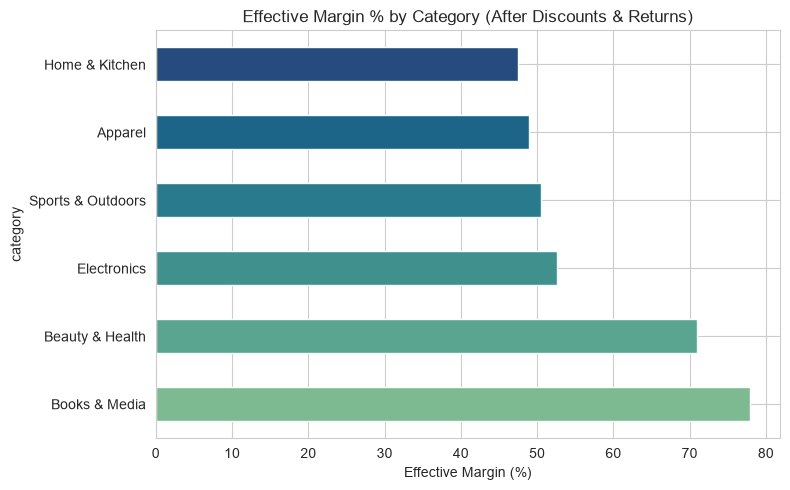

In [38]:
fig, ax = plt.subplots(figsize=(8, 5))
category_margin["effective_margin_pct"].plot(kind="barh", ax=ax, color=sns.color_palette("crest", len(category_margin)))
ax.set_title("Effective Margin % by Category (After Discounts & Returns)")
ax.set_xlabel("Effective Margin (%)")
plt.tight_layout()
plt.savefig(PROCESSED.parent / "chart_q3_margin.png", dpi=150)
plt.show()

**Write your interpretation here** — which category wins, and is the ranking different from what you'd get using list price alone (i.e., does the discount/return adjustment change the answer)?

---
## Q4 — Do higher review ratings correlate with repeat-purchase behavior?

In [39]:
# Repeat purchaser = frequency > 1 completed order (already computed in Phase 3's rfm_raw)
avg_rating_per_customer = reviews.groupby("customer_id")["rating"].mean().reset_index()
avg_rating_per_customer.columns = ["customer_id", "avg_rating"]

rating_vs_repeat = rfm_raw[["customer_id", "frequency"]].merge(avg_rating_per_customer, on="customer_id")
rating_vs_repeat["is_repeat_purchaser"] = rating_vs_repeat["frequency"] > 1

# Correlation coefficient, computed with plain NumPy (consistent with Phase 3's "no shortcuts" spirit)
x = rating_vs_repeat["avg_rating"].to_numpy()
y = rating_vs_repeat["frequency"].to_numpy()
correlation = np.corrcoef(x, y)[0, 1]
print(f"Correlation (avg rating vs. purchase frequency): {correlation:.4f}")

# Also compare average rating: repeat vs one-time buyers
comparison = rating_vs_repeat.groupby("is_repeat_purchaser")["avg_rating"].mean()
print(comparison)

Correlation (avg rating vs. purchase frequency): 0.0361
is_repeat_purchaser
False    3.925269
True     3.955826
Name: avg_rating, dtype: float64


C:\Users\Dell\AppData\Local\Temp\ipykernel_29400\1566086639.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["One-time buyer", "Repeat buyer"])


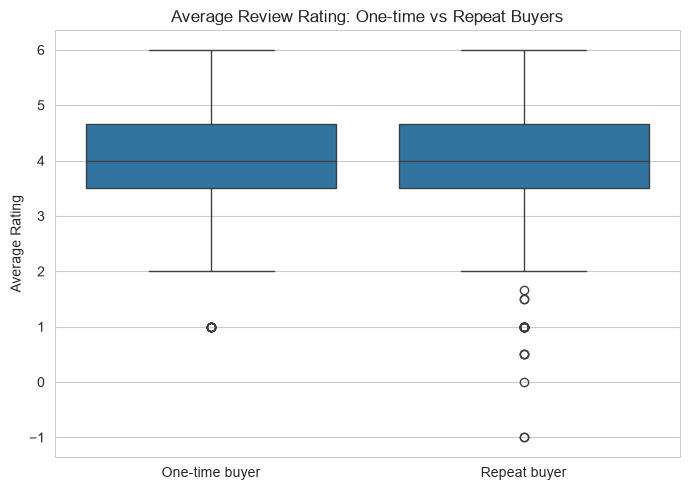

In [40]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=rating_vs_repeat, x="is_repeat_purchaser", y="avg_rating", ax=ax)
ax.set_xticklabels(["One-time buyer", "Repeat buyer"])
ax.set_title("Average Review Rating: One-time vs Repeat Buyers")
ax.set_ylabel("Average Rating")
ax.set_xlabel("")
plt.tight_layout()
plt.savefig(PROCESSED.parent / "chart_q4_rating_repeat.png", dpi=150)
plt.show()

**Write your interpretation here** — is the correlation meaningfully positive, near zero, or even negative? A near-zero correlation is a legitimate, reportable finding — don't force a story that isn't in the numbers.

---
## Q5 — Which device × country combination shows the highest engagement-to-purchase conversion?

In [41]:
# Conversion here = of customers who had at least one session on a given device,
# in a given country, what share went on to place at least one completed order?
sessions_with_country = web_sessions.merge(customers[["customer_id", "country"]], on="customer_id")

purchasers = set(orders_completed["customer_id"])

device_country = sessions_with_country.groupby(["device", "country"])["customer_id"].apply(
    lambda ids: pd.Series({
        "session_customers": ids.nunique(),
        "purchasers": len(set(ids) & purchasers),
    })
).unstack()

device_country["conversion_rate"] = device_country["purchasers"] / device_country["session_customers"]

# Filter out tiny/noisy combinations (require at least 20 customers in the group)
device_country_filtered = device_country[device_country["session_customers"] >= 20]
device_country_filtered = device_country_filtered.sort_values("conversion_rate", ascending=False)
print(device_country_filtered.head(10))

                   session_customers  purchasers  conversion_rate
device  country                                                  
tablet  Singapore                148         134         0.905405
mobile  Singapore                136         123         0.904412
        Thailand                 133         120         0.902256
desktop Thailand                 131         118         0.900763
tablet  Thailand                 133         119         0.894737
desktop Australia                295         262         0.888136
tablet  Germany                  268         238         0.888060
desktop Singapore                141         125         0.886525
        USA                      409         359         0.877751
tablet  Canada                   258         226         0.875969


C:\Users\Dell\AppData\Local\Temp\ipykernel_29400\1074682924.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10, y="label", x="conversion_rate", ax=ax, palette="flare")


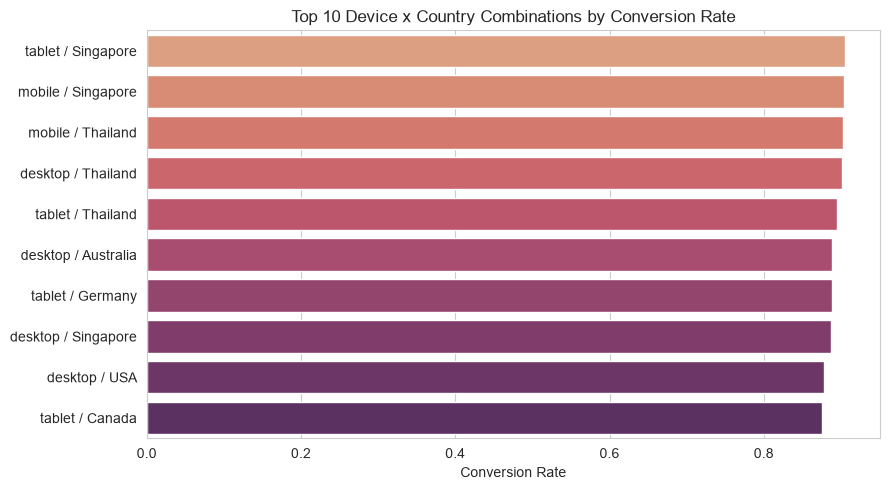

In [42]:
top10 = device_country_filtered.head(10).reset_index()
top10["label"] = top10["device"] + " / " + top10["country"]

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=top10, y="label", x="conversion_rate", ax=ax, palette="flare")
ax.set_title("Top 10 Device x Country Combinations by Conversion Rate")
ax.set_xlabel("Conversion Rate")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(PROCESSED.parent / "chart_q5_conversion.png", dpi=150)
plt.show()

**Write your interpretation here** — name the winning combination and its conversion rate, and note the minimum sample size you required (here: 20+ customers) so the finding isn't just noise.

---
## Q6 — Projected revenue for the next 2 months, with an uncertainty range

In [43]:
monthly_revenue_arr = category_month_revenue.sum(axis=0).sort_index().to_numpy()
n_months = len(monthly_revenue_arr)
X_raw = np.arange(n_months).reshape(-1, 1)
X = np.hstack([np.ones((n_months, 1)), X_raw])
y = monthly_revenue_arr.reshape(-1, 1)

y_pred = X @ beta
residuals = y - y_pred
n, p = X.shape  # n = observations, p = number of parameters (intercept + slope = 2)
residual_var = np.sum(residuals ** 2) / (n - p)  # unbiased estimate of error variance

x_mean = X_raw.mean()
Sxx = np.sum((X_raw - x_mean) ** 2)

future_months = np.array([n_months, n_months + 1])
forecasts = []
for fm in future_months:
    x0 = np.array([1, fm])
    point_forecast = (x0 @ beta)[0]
    # Prediction interval standard error (accounts for both parameter uncertainty
    # and the natural variance of a NEW observation)
    se_pred = np.sqrt(residual_var * (1 + 1/n + ((fm - x_mean) ** 2) / Sxx))
    forecasts.append({
        "month_index": fm,
        "point_forecast": point_forecast,
        "lower_95": point_forecast - 1.96 * se_pred,
        "upper_95": point_forecast + 1.96 * se_pred,
})

forecast_df = pd.DataFrame(forecasts)
print(forecast_df)

   month_index  point_forecast       lower_95       upper_95
0           36   547844.115383  428162.983747  667525.247018
1           37   557984.642140  437780.121135  678189.163146


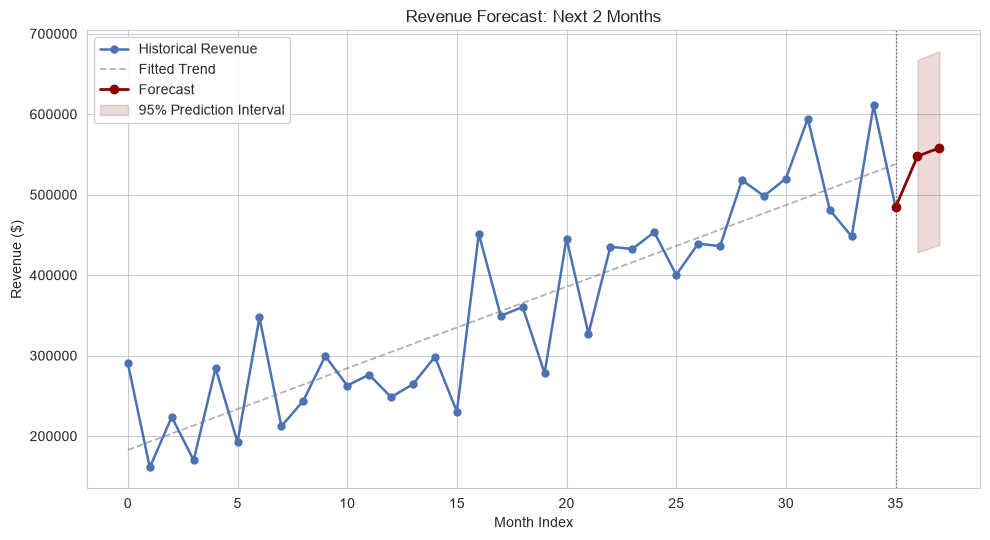

In [44]:
fig, ax = plt.subplots(figsize=(10, 5.5))

# Actual revenue: keep this the most visually dominant line
ax.plot(range(n_months), monthly_revenue_arr, marker="o", markersize=5,
        color="#4C72B0", linewidth=1.8, label="Historical Revenue", zorder=3)

# Fitted trend: make it lighter, thinner, and drawn BEHIND the actual line (zorder=1)
# so it reads as a background reference rather than competing for attention
ax.plot(range(n_months), y_pred.flatten(), linestyle="--", color="gray",
        linewidth=1.3, alpha=0.6, label="Fitted Trend", zorder=1)

# Forecast: distinct color, connected to the last historical point for continuity
future_x = forecast_df["month_index"].to_numpy()
connect_x = [n_months - 1] + list(future_x)
connect_y = [monthly_revenue_arr[-1]] + list(forecast_df["point_forecast"])
ax.plot(connect_x, connect_y, marker="o", markersize=6, color="darkred",
        linewidth=2, label="Forecast", zorder=3)

ax.fill_between(future_x, forecast_df["lower_95"], forecast_df["upper_95"],
                 color="darkred", alpha=0.15, label="95% Prediction Interval", zorder=2)

# Vertical line marking where history ends and forecast begins — removes ambiguity
ax.axvline(x=n_months - 1, color="black", linestyle=":", linewidth=1, alpha=0.5)

ax.set_title("Revenue Forecast: Next 2 Months")
ax.set_xlabel("Month Index")
ax.set_ylabel("Revenue ($)")
ax.legend(loc="upper left", framealpha=0.9)
plt.tight_layout()
plt.savefig(PROCESSED.parent / "chart_q6_forecast.png", dpi=150)
plt.show()

**Write your interpretation here** — state the 2 point forecasts and their ranges in plain dollars, and be upfront that a straight-line trend is a simplification (mention Q2's seasonality finding as a caveat here — nice callback between questions).

---
## Q7 — Top 5 stockout-risk products, with recommended reorder points

In [45]:
# Extend Phase 3's Monte Carlo to ALL eligible products (not just the 3 minimum from Phase 3),
# so we can genuinely rank and pick the top 5 riskiest.
catalog = pd.read_csv(RAW / "product_catalog_2024.csv")
catalog = catalog.rename(columns={"SKU": "product_id", "in_stock_units": "stock_units"})

orders_completed_ids = orders_completed[["order_id", "order_date"]]
purchases = order_items_clean.merge(orders_completed_ids, on="order_id")
purchases = purchases[purchases["quantity"] > 0]
purchases["month"] = purchases["order_date"].apply(lambda d: pd.Period(pd.to_datetime(d), freq="M"))

monthly_demand = purchases.groupby(["product_id", "month"])["quantity"].sum().reset_index()
demand_stats = monthly_demand.groupby("product_id")["quantity"].agg(["mean", "std"]).reset_index().dropna()
demand_stats = demand_stats.merge(catalog[["product_id", "stock_units"]], on="product_id", how="inner")

np.random.seed(42)
n_trials = 5000
rows = []
for _, r in demand_stats.iterrows():
    sim = np.clip(np.random.normal(r["mean"], r["std"], n_trials), 0, None)
    stockout_prob = (sim > r["stock_units"]).mean()
    se = np.sqrt(stockout_prob * (1 - stockout_prob) / n_trials)
    # Reorder point recommendation: mean demand + 1.65 std (covers ~95% of demand outcomes)
    reorder_point = r["mean"] + 1.65 * r["std"]
    rows.append({
        "product_id": r["product_id"], "stock": r["stock_units"], "mean_monthly_demand": round(r["mean"], 1),
        "stockout_probability": round(stockout_prob, 4),
        "ci_95": (round(max(0, stockout_prob - 1.96*se), 4), round(min(1, stockout_prob + 1.96*se), 4)),
        "recommended_reorder_point": round(reorder_point, 1),
    })

all_stockout_risk = pd.DataFrame(rows).sort_values("stockout_probability", ascending=False)
top5_risk = all_stockout_risk.merge(products[["product_id", "name", "category"]], on="product_id").head(5)
print(top5_risk)

   product_id  stock  mean_monthly_demand  stockout_probability  \
0       300.0    0.0                  1.9                0.9654   
1       222.0    3.0                  2.0                0.1504   
2       105.0    4.0                  2.1                0.1292   
3         9.0    5.0                  2.1                0.0118   
4       127.0    6.0                  2.2                0.0018   

              ci_95  recommended_reorder_point               name  \
0  (0.9603, 0.9705)                        3.7  Those Non-Fiction   
1  (0.1405, 0.1603)                        3.6     Car Supplement   
2  (0.1199, 0.1385)                        4.9  Physical Footwear   
3  (0.0088, 0.0148)                        4.2       Right Laptop   
4   (0.0006, 0.003)                        4.5  Research Footwear   

          category  
0    Books & Media  
1  Beauty & Health  
2          Apparel  
3      Electronics  
4          Apparel  


C:\Users\Dell\AppData\Local\Temp\ipykernel_29400\1831183900.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top5_risk, y="name", x="stockout_probability", ax=ax, palette="rocket")


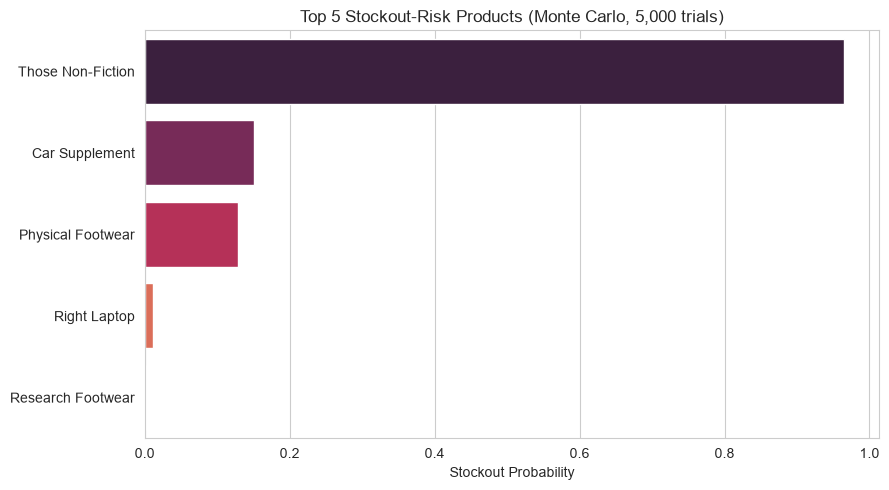

In [46]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=top5_risk, y="name", x="stockout_probability", ax=ax, palette="rocket")
ax.set_title("Top 5 Stockout-Risk Products (Monte Carlo, 5,000 trials)")
ax.set_xlabel("Stockout Probability")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(PROCESSED.parent / "chart_q7_stockout.png", dpi=150)
plt.show()

**Write your interpretation here** — list the 5 products, their probabilities + CIs, and their recommended reorder points from the table above.

---
## Q8 — Data-quality finding that materially changed a conclusion

In [47]:
# Compare naive revenue (all order statuses, uncleaned) vs. cleaned (completed orders only)
oi_naive = order_items_clean.merge(orders[["order_id", "status"]], on="order_id")
oi_naive["naive_revenue"] = oi_naive["unit_price"] * oi_naive["quantity"] * (1 - oi_naive["discount"])

naive_total = oi_naive["naive_revenue"].sum()
cleaned_total = order_items_clean.merge(
    orders_completed[["order_id"]], on="order_id"
)["net_revenue"].sum()

pct_diff = (naive_total - cleaned_total) / cleaned_total * 100
print(f"Naive total revenue (all order statuses included): ${naive_total:,.2f}")
print(f"Cleaned total revenue (completed orders only):      ${cleaned_total:,.2f}")
print(f"Overstatement if uncleaned: {pct_diff:.1f}%")

status_breakdown = orders["status"].value_counts(normalize=True) * 100
print(status_breakdown)

Naive total revenue (all order statuses included): $12,968,797.33
Cleaned total revenue (completed orders only):      $7,569,487.97
Overstatement if uncleaned: 71.3%
status
completed    56.677778
cancelled    14.755556
returned     14.744444
pending      13.822222
Name: proportion, dtype: float64


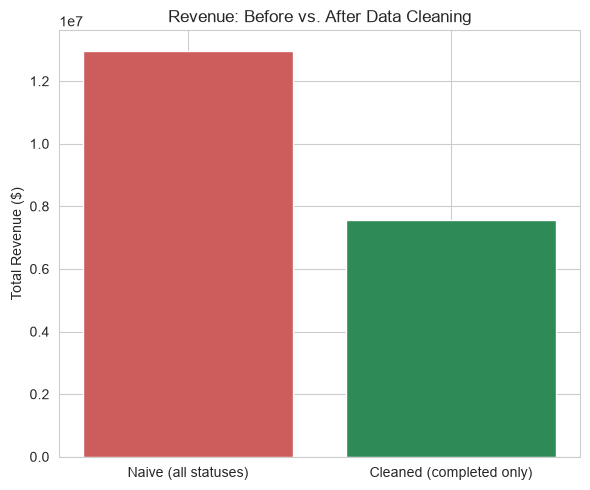

In [48]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(["Naive (all statuses)", "Cleaned (completed only)"], [naive_total, cleaned_total],
       color=["indianred", "seagreen"])
ax.set_title("Revenue: Before vs. After Data Cleaning")
ax.set_ylabel("Total Revenue ($)")
plt.tight_layout()
plt.savefig(PROCESSED.parent / "chart_q8_dataquality.png", dpi=150)
plt.show()

**Write your interpretation here** — e.g. "*Including cancelled, returned, and pending orders as if they were real sales overstates revenue by ~71%. Since ~43% of all orders never actually completed, any leadership decision based on raw order counts (e.g. inventory planning, revenue targets) would have been built on badly inflated numbers.*" This is a strong, quantified example — use the real percentage your run produces.

---
## Summary table of saved charts
All 8 charts are saved as PNGs one level up from `data/processed/` (in your project root) — pull these directly into your report rather than re-generating them there.

In [49]:
import os
chart_files = sorted([f for f in os.listdir(PROCESSED.parent) if f.startswith("chart_")])
for f in chart_files:
    print(f)

chart_q1_segment_revenue.png
chart_q2_seasonality.png
chart_q3_margin.png
chart_q4_rating_repeat.png
chart_q5_conversion.png
chart_q6_forecast.png
chart_q7_stockout.png
chart_q8_dataquality.png
